# 반도체 웨이퍼 포트폴리오 발표용 이미지 생성

이 Notebook은 `LSWMD.pkl`의 실제 웨이퍼 맵과 프로젝트의 최종 모델링 Notebook인 `modeling.ipynb`에 정의된 전처리를 기준으로 발표용 PNG를 재현 가능하게 생성한다. 기존 파일은 변경하지 않으며 결과는 `data/wafer_images` 아래에만 저장한다.

## 구현 기준

기존 `modeling.ipynb`의 `preprocess_fixed_resize`, `preprocess_resize_pad`, `preprocess_resize_pad_with_mask`, `WaferDataset`, `ExperimentConfig`를 기준으로 삼았다. 실제 실험 입력은 64×64이며, resize는 `cv2.INTER_NEAREST`를 사용한다. fixed resize와 resize+padding은 1채널, padding mask 실험은 웨이퍼 맵과 mask를 결합한 2채널 입력이다. 원본 맵 값은 0=웨이퍼 바깥, 1=정상 셀, 2=불량 셀이고 모델 입력에서는 2로 나누어 정규화한다.

기존 프로젝트의 mask 함수는 웨이퍼 모양 자체가 아니라 **비율 유지 resize 후 패딩을 제외한 유효 사각 영역**을 1로 표시한다. 이 코드는 비교 근거로 그대로 유지한다. 다만 발표용 `preprocess_04_mask.png`는 의도에 맞게 padding 결과에서 값이 0보다 큰 실제 웨이퍼 셀 영역만 1로 표시하며, 기존 `modeling.ipynb`는 수정하지 않는다.

실행 환경은 기존 `modeling.ipynb`와 동일하게 `pandas`, `numpy`, `matplotlib`, `Pillow`, `opencv-python`이 필요하다.

## 1. Imports / Paths

In [41]:
from __future__ import annotations

import math
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

WORKING_DIR = Path.cwd().resolve()
NOTEBOOK_DIR = (
    WORKING_DIR
    if (WORKING_DIR / "data" / "LSWMD.pkl").exists()
    else WORKING_DIR / "notebooks"
)
DATA_PATH = NOTEBOOK_DIR / "data" / "LSWMD.pkl"
OUTPUT_DIR = NOTEBOOK_DIR / "data" / "wafer_images"
COVER_DIR = OUTPUT_DIR / "cover"
PREPROCESS_DIR = OUTPUT_DIR / "preprocessing"

for directory in (COVER_DIR, PREPROCESS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = 64
COVER_MIN_LONG_EDGE = 1600
PREPROCESS_CANVAS_SIZE = 1280

CLASSES = [
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
    "none",
]
DEFECT_CLASSES = CLASSES[:-1]

BACKGROUND_GRAY = (128, 128, 128, 255)
NORMAL_WHITE = (255, 255, 255, 255)
DEFECT_RED = (220, 38, 38, 255)
TRANSPARENT = (0, 0, 0, 0)

print(f"Raw data: {DATA_PATH}")
print(f"Output: {OUTPUT_DIR}")

Raw data: C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\LSWMD.pkl
Output: C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images


## 2. Raw Data Load

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Raw 데이터가 없습니다: {DATA_PATH}")

raw_df = pd.read_pickle(DATA_PATH)
raw_df = raw_df.rename(columns={"trianTestLabel": "trainTestLabel"})
print(f"raw_df shape: {raw_df.shape}")
display(raw_df.head())

raw_df shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## 3. Dataset Structure 확인

In [12]:
def unpack_nested_label(value: object) -> str:
    """중첩 ndarray 라벨을 프로젝트와 같은 문자열로 변환한다.

    Args:
        value: 원본 failureType 또는 trainTestLabel 값.

    Returns:
        펼친 문자열 라벨. 값이 비어 있으면 unknown.
    """
    if isinstance(value, np.ndarray) and value.size > 0:
        return str(value.reshape(-1)[0])
    return "unknown"


failure_types = raw_df["failureType"].map(unpack_nested_label)
train_test_labels = raw_df["trainTestLabel"].map(unpack_nested_label)

schema_df = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "non_null": raw_df.notna().sum(),
        "sample_type": [
            type(raw_df[column].iloc[0]).__name__
            for column in raw_df.columns
        ],
    }
)
display(schema_df)
print("failureType counts:")
display(failure_types.value_counts().reindex(CLASSES + ["unknown"]))
print("trainTestLabel counts:")
display(train_test_labels.value_counts())

verification_indices = raw_df.index[:500]
observed_values = sorted(
    {
        int(value)
        for wafer_map in raw_df.loc[verification_indices, "waferMap"]
        for value in np.unique(wafer_map)
    }
)
print(f"결정적 앞 500개 맵에서 확인한 셀 값: {observed_values}")
assert set(observed_values).issubset({0, 1, 2})

,dtype,non_null,sample_type
waferMap,object,811457,ndarray
dieSize,float64,811457,float64
lotName,object,811457,str_
waferIndex,float64,811457,float64
trainTestLabel,object,811457,ndarray
failureType,object,811457,ndarray


failureType counts:


failureType
Center         4294
Donut           555
Edge-Loc       5189
Edge-Ring      9680
Loc            3593
Random          866
Scratch        1193
Near-full       149
none         147431
unknown      638507
Name: count, dtype: int64

trainTestLabel counts:


trainTestLabel
unknown     638507
Test        118595
Training     54355
Name: count, dtype: int64

결정적 앞 500개 맵에서 확인한 셀 값: [0, 1, 2]


## 4. 기존 preprocessing 구현 확인 및 함수 정리

아래 세 함수는 `modeling.ipynb`의 구현을 동작 변경 없이 정리한 것이다. padding 값 0, 중앙 배치, 반올림 방식, 최근접 interpolation을 그대로 유지한다.

In [13]:
def preprocess_fixed_resize(
    wafer_map: np.ndarray,
    target_size: int,
) -> np.ndarray:
    """비율을 무시하고 고정 크기로 최근접 리사이즈한다.

    Args:
        wafer_map: 원본 웨이퍼 맵.
        target_size: 정사각형 목표 크기.

    Returns:
        리사이즈된 웨이퍼 맵.
    """
    return cv2.resize(
        wafer_map,
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST,
    )


def preprocess_resize_pad(
    wafer_map: np.ndarray,
    target_size: int,
) -> np.ndarray:
    """비율 유지 리사이즈 후 zero padding을 적용한다.

    Args:
        wafer_map: 원본 웨이퍼 맵.
        target_size: 정사각형 목표 크기.

    Returns:
        중앙 정렬된 패딩 웨이퍼 맵.
    """
    height, width = wafer_map.shape
    scale = min(target_size / height, target_size / width)
    new_height = max(1, int(round(height * scale)))
    new_width = max(1, int(round(width * scale)))

    resized = cv2.resize(
        wafer_map,
        (new_width, new_height),
        interpolation=cv2.INTER_NEAREST,
    )
    padded = np.zeros((target_size, target_size), dtype=np.uint8)
    top = (target_size - new_height) // 2
    left = (target_size - new_width) // 2
    padded[top:top + new_height, left:left + new_width] = resized
    return padded


def preprocess_resize_pad_with_mask(
    wafer_map: np.ndarray,
    target_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    """비율 유지 리사이즈, zero padding, 유효 영역 mask를 생성한다.

    Args:
        wafer_map: 원본 웨이퍼 맵.
        target_size: 정사각형 목표 크기.

    Returns:
        패딩된 맵과 리사이즈 유효 사각 영역 mask.
    """
    height, width = wafer_map.shape
    scale = min(target_size / height, target_size / width)
    new_height = max(1, int(round(height * scale)))
    new_width = max(1, int(round(width * scale)))

    resized = cv2.resize(
        wafer_map,
        (new_width, new_height),
        interpolation=cv2.INTER_NEAREST,
    )
    padded = np.zeros((target_size, target_size), dtype=np.uint8)
    mask = np.zeros((target_size, target_size), dtype=np.uint8)
    top = (target_size - new_height) // 2
    left = (target_size - new_width) // 2
    padded[top:top + new_height, left:left + new_width] = resized
    mask[top:top + new_height, left:left + new_width] = 1
    return padded, mask


print(f"모델 입력 크기: {TARGET_SIZE} × {TARGET_SIZE}")
print("입력 채널: fixed/padding=1, padding+mask=2")
display(pd.DataFrame({"label_id": range(len(CLASSES)), "class": CLASSES}))

모델 입력 크기: 64 × 64
입력 채널: fixed/padding=1, padding+mask=2


,label_id,class
0,0,Center
1,1,Donut
2,2,Edge-Loc
3,3,Edge-Ring
4,4,Loc
5,5,Random
6,6,Scratch
7,7,Near-full
8,8,none


### 발표용 raster 저장 함수

셀 맵을 먼저 정확한 RGBA 색으로 변환한 뒤 정수 배율의 최근접 방식으로만 확대한다. 저장 과정에 matplotlib을 사용하지 않으므로 axis, tick, title, margin, smoothing이 PNG에 들어가지 않는다.

In [14]:
def map_to_rgba(
    wafer_map: np.ndarray,
    background: tuple[int, int, int, int],
) -> np.ndarray:
    """웨이퍼 값 0/1/2를 고정 RGBA 색상으로 변환한다.

    Args:
        wafer_map: 값이 0, 1, 2인 웨이퍼 맵.
        background: 값 0에 사용할 RGBA 색.

    Returns:
        RGBA 이미지 배열.
    """
    unique_values = set(np.unique(wafer_map).tolist())
    if not unique_values.issubset({0, 1, 2}):
        raise ValueError(f"예상하지 못한 셀 값: {sorted(unique_values)}")

    rgba = np.empty((*wafer_map.shape, 4), dtype=np.uint8)
    rgba[wafer_map == 0] = background
    rgba[wafer_map == 1] = NORMAL_WHITE
    rgba[wafer_map == 2] = DEFECT_RED
    return rgba


def resize_nearest(image: Image.Image, size: tuple[int, int]) -> Image.Image:
    """Pillow 최근접 방식으로 이미지를 리사이즈한다.

    Args:
        image: 원본 Pillow 이미지.
        size: 목표 (width, height).

    Returns:
        최근접 리사이즈된 이미지.
    """
    return image.resize(size, resample=Image.Resampling.NEAREST)


def save_cover_png(wafer_map: np.ndarray, output_path: Path) -> None:
    """투명 배경의 고해상도 cover PNG를 저장한다.

    Args:
        wafer_map: 동일 shape 그룹에서 선택한 원본 맵.
        output_path: 저장 경로.
    """
    height, width = wafer_map.shape
    scale = max(1, math.ceil(COVER_MIN_LONG_EDGE / max(height, width)))
    image = Image.fromarray(map_to_rgba(wafer_map, TRANSPARENT), "RGBA")
    image = resize_nearest(image, (width * scale, height * scale))
    image.save(output_path, format="PNG")


def save_original_png(wafer_map: np.ndarray, output_path: Path) -> None:
    """외부 canvas 없이 raw 비율 그대로 Original PNG를 저장한다.

    Args:
        wafer_map: 원본 웨이퍼 맵.
        output_path: 저장 경로.
    """
    height, width = wafer_map.shape
    scale = max(
        1,
        math.ceil(PREPROCESS_CANVAS_SIZE / max(height, width)),
    )
    image = Image.fromarray(
        map_to_rgba(wafer_map, BACKGROUND_GRAY),
        "RGBA",
    )
    image = resize_nearest(image, (width * scale, height * scale))
    image.save(output_path, format="PNG")


def save_square_map_png(wafer_map: np.ndarray, output_path: Path) -> None:
    """웨이퍼 맵을 1280 정사각 발표용 PNG로 저장한다.

    Args:
        wafer_map: 64×64 전처리 웨이퍼 맵.
        output_path: 저장 경로.
    """
    height, width = wafer_map.shape
    scale = max(1, PREPROCESS_CANVAS_SIZE // max(height, width))
    image = Image.fromarray(map_to_rgba(wafer_map, BACKGROUND_GRAY), "RGBA")
    image = resize_nearest(image, (width * scale, height * scale))
    canvas = Image.new("RGBA", (PREPROCESS_CANVAS_SIZE,) * 2, BACKGROUND_GRAY)
    left = (PREPROCESS_CANVAS_SIZE - image.width) // 2
    top = (PREPROCESS_CANVAS_SIZE - image.height) // 2
    canvas.paste(image, (left, top))
    canvas.save(output_path, format="PNG")


def save_mask_png(mask: np.ndarray, output_path: Path) -> None:
    """0=회색, 1=흰색으로 mask PNG를 저장한다.

    Args:
        mask: 실제 웨이퍼 셀 영역을 나타내는 binary mask.
        output_path: 저장 경로.
    """
    if not set(np.unique(mask).tolist()).issubset({0, 1}):
        raise ValueError("Mask에는 0과 1만 있어야 합니다.")
    rgba = np.empty((*mask.shape, 4), dtype=np.uint8)
    rgba[mask == 0] = BACKGROUND_GRAY
    rgba[mask == 1] = NORMAL_WHITE
    image = Image.fromarray(rgba, "RGBA")
    image = resize_nearest(
        image,
        (PREPROCESS_CANVAS_SIZE, PREPROCESS_CANVAS_SIZE),
    )
    image.save(output_path, format="PNG")

In [44]:
print(raw_df['waferMap'][0])

sample_index = 0
sample_wafer_map = raw_df.iloc[sample_index]["waferMap"].astype(
    np.uint8,
    copy=False,
)

raw_wafer_path = OUTPUT_DIR / "raw_wafer_map_000.png"

save_original_png(
    sample_wafer_map,
    raw_wafer_path,
)

print(raw_wafer_path)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\raw_wafer_map_000.png


C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:64: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


## 5. Cover Sample 후보 탐색

라벨이 있는 불량 웨이퍼만 대상으로 raw shape를 직접 계산한다. shape별 서로 다른 defect class 수를 최우선으로, 샘플 수와 lot 수를 다음 기준으로 정렬한다.

In [15]:
valid_index = failure_types[failure_types.isin(CLASSES)].index
metadata_df = pd.DataFrame(index=valid_index)
metadata_df["failure_type"] = failure_types.loc[valid_index]
metadata_df["lot_name"] = raw_df.loc[valid_index, "lotName"].astype(str)
metadata_df["wafer_index"] = raw_df.loc[valid_index, "waferIndex"]

shapes = [raw_df.at[index, "waferMap"].shape for index in valid_index]
metadata_df["height"] = [shape[0] for shape in shapes]
metadata_df["width"] = [shape[1] for shape in shapes]
metadata_df["raw_shape"] = shapes
metadata_df["aspect_ratio"] = (
    metadata_df["width"] / metadata_df["height"]
)
metadata_df["shape_distortion"] = metadata_df[["aspect_ratio"]].apply(
    lambda row: max(row.iloc[0], 1.0 / row.iloc[0]),
    axis=1,
)

defect_metadata = metadata_df[
    metadata_df["failure_type"].isin(DEFECT_CLASSES)
].copy()

shape_summary = (
    defect_metadata.groupby(["height", "width"])
    .agg(
        class_count=("failure_type", "nunique"),
        sample_count=("failure_type", "size"),
        lot_count=("lot_name", "nunique"),
    )
    .reset_index()
    .sort_values(
        ["class_count", "sample_count", "lot_count", "height", "width"],
        ascending=[False, False, False, True, True],
        kind="stable",
    )
)
display(shape_summary.head(15))

,height,width,class_count,sample_count,lot_count
77,39,37,8,1015,382
5,26,26,8,877,503
26,30,34,8,710,420
49,35,31,8,648,205
113,44,41,8,600,215
17,29,26,8,555,306
40,33,29,8,401,252
89,41,33,8,307,149
2,25,26,8,267,135
69,38,38,8,222,87


## 6. Cover Sample 최종 선정

최상위 shape 그룹에서 클래스별 defect ratio의 75% 분위수에 가장 가까운 샘플을 선택한다. 이 데이터 기반 기준은 지나치게 희미한 샘플을 피하면서 최댓값의 과포화도 방지한다. 동률이면 유효 웨이퍼 셀 수와 원본 index로 결정하며, 최대 8개 defect class를 사용한다. 최소 6개가 확보되지 않으면 명시적으로 중단한다.

In [16]:
cover_height = int(shape_summary.iloc[0]["height"])
cover_width = int(shape_summary.iloc[0]["width"])
cover_candidates = defect_metadata[
    (defect_metadata["height"] == cover_height)
    & (defect_metadata["width"] == cover_width)
].copy()

cover_candidates["defect_cells"] = [
    int(np.count_nonzero(raw_df.at[index, "waferMap"] == 2))
    for index in cover_candidates.index
]
cover_candidates["wafer_cells"] = [
    int(np.count_nonzero(raw_df.at[index, "waferMap"] > 0))
    for index in cover_candidates.index
]
cover_candidates["defect_ratio"] = (
    cover_candidates["defect_cells"]
    / cover_candidates["wafer_cells"].clip(lower=1)
)
cover_candidates["df_index"] = cover_candidates.index

selected_cover_rows = []
for defect_class in DEFECT_CLASSES:
    class_candidates = cover_candidates[
        cover_candidates["failure_type"] == defect_class
    ].copy()
    target_ratio = class_candidates["defect_ratio"].quantile(
        0.75,
        interpolation="nearest",
    )
    class_candidates["target_ratio_q75"] = target_ratio
    class_candidates["selection_distance"] = (
        class_candidates["defect_ratio"] - target_ratio
    ).abs()
    class_candidates = class_candidates.sort_values(
        ["selection_distance", "wafer_cells", "df_index"],
        ascending=[True, False, True],
        kind="stable",
    )
    if not class_candidates.empty:
        selected_cover_rows.append(class_candidates.iloc[0])

selected_cover_df = pd.DataFrame(selected_cover_rows).set_index("df_index")
selected_cover_df.index.name = "df_index"
if len(selected_cover_df) < 6:
    raise RuntimeError("동일 raw shape에서 defect class 6개를 확보하지 못했습니다.")

assert selected_cover_df[["height", "width"]].drop_duplicates().shape[0] == 1
cover_columns = [
    "failure_type",
    "lot_name",
    "wafer_index",
    "raw_shape",
    "defect_cells",
    "wafer_cells",
    "defect_ratio",
    "target_ratio_q75",
]
print(f"선택된 공통 raw shape: ({cover_height}, {cover_width})")
display(selected_cover_df[cover_columns])

선택된 공통 raw shape: (39, 37)


,failure_type,lot_name,wafer_index,raw_shape,defect_cells,wafer_cells,defect_ratio,target_ratio_q75
df_index,,,,,,,,
757757,Center,lot45357,18.0,"(39, 37)",132,1109,0.119026,0.119026
762985,Donut,lot45569,9.0,"(39, 37)",402,1109,0.362489,0.362489
756646,Edge-Loc,lot45313,1.0,"(39, 37)",160,1109,0.144274,0.144274
762937,Edge-Ring,lot45567,11.0,"(39, 37)",210,1109,0.189360,0.189360
758568,Loc,lot45390,10.0,"(39, 37)",170,1109,0.153291,0.153291
759877,Random,lot45443,24.0,"(39, 37)",593,1109,0.534716,0.534716
762324,Scratch,lot45542,22.0,"(39, 37)",146,1109,0.131650,0.131650
763098,Near-full,lot45573,22.0,"(39, 37)",966,1109,0.871055,0.871055


## 7. Cover 이미지 생성 및 저장

In [17]:
def slugify_class_name(class_name: str) -> str:
    """클래스 이름을 안전한 소문자 파일명으로 변환한다.

    Args:
        class_name: defect class 이름.

    Returns:
        파일명에 사용할 slug.
    """
    return re.sub(r"[^a-z0-9]+", "_", class_name.lower()).strip("_")


cover_paths = []
for df_index, row in selected_cover_df.iterrows():
    filename = f"cover_{slugify_class_name(row['failure_type'])}.png"
    output_path = COVER_DIR / filename
    wafer_map = raw_df.at[df_index, "waferMap"].astype(np.uint8, copy=False)
    save_cover_png(wafer_map, output_path)
    cover_paths.append(output_path)

print(f"Cover PNG {len(cover_paths)}개 저장 완료")
for path in cover_paths:
    print(path)

C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:47: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(map_to_rgba(wafer_map, TRANSPARENT), "RGBA")


Cover PNG 8개 저장 완료
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_center.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_donut.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_edge_loc.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_edge_ring.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_loc.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_random.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_scratch.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\cover\cover_near_full.png


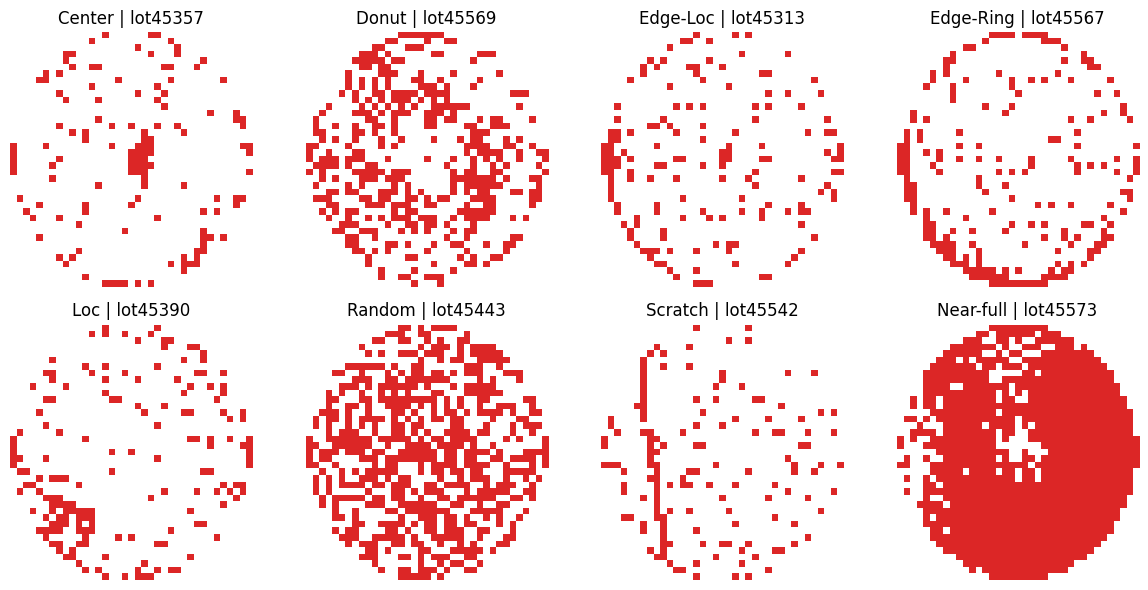

In [19]:
preview_columns = 4
preview_rows = math.ceil(len(selected_cover_df) / preview_columns)
figure, axes = plt.subplots(
    preview_rows,
    preview_columns,
    figsize=(12, 3 * preview_rows),
)
axes = np.atleast_1d(axes).ravel()
for axis, (df_index, row) in zip(axes, selected_cover_df.iterrows()):
    axis.imshow(
        map_to_rgba(raw_df.at[df_index, "waferMap"], TRANSPARENT),
        interpolation="nearest",
    )
    axis.set_title(f"{row['failure_type']} | {row['lot_name']}")
    axis.axis("off")
for axis in axes[len(selected_cover_df):]:
    axis.axis("off")
# figure.suptitle("Cover wafer preview — 저장 PNG에는 제목이 없음")
figure.tight_layout()
plt.show()

## 8. Elliptical Wafer 후보 탐색

shape distortion은 `max(width/height, height/width)`로 정의한다. 데이터 오류처럼 보이는 극단값을 피하기 위해 양 변 20~100 셀, distortion 1.25~2.0, 유효 웨이퍼 셀 300개 이상, 불량 셀 10개 이상인 실제 defect 샘플만 후보로 사용한다.

In [20]:
ellipse_candidates = defect_metadata.copy()
ellipse_candidates["defect_cells"] = [
    int(np.count_nonzero(raw_df.at[index, "waferMap"] == 2))
    for index in ellipse_candidates.index
]
ellipse_candidates["wafer_cells"] = [
    int(np.count_nonzero(raw_df.at[index, "waferMap"] > 0))
    for index in ellipse_candidates.index
]
ellipse_candidates["df_index"] = ellipse_candidates.index
ellipse_candidates = ellipse_candidates[
    ellipse_candidates["height"].between(20, 100)
    & ellipse_candidates["width"].between(20, 100)
    & ellipse_candidates["shape_distortion"].between(1.25, 2.0)
    & (ellipse_candidates["wafer_cells"] >= 300)
    & (ellipse_candidates["defect_cells"] >= 10)
].copy()
ellipse_candidates["presentation_score"] = (
    ellipse_candidates["shape_distortion"]
    + 0.02 * np.log1p(ellipse_candidates["defect_cells"])
)
ellipse_candidates = ellipse_candidates.sort_values(
    ["presentation_score", "wafer_cells", "df_index"],
    ascending=[False, False, True],
    kind="stable",
)
candidate_columns = [
    "failure_type",
    "lot_name",
    "wafer_index",
    "raw_shape",
    "aspect_ratio",
    "shape_distortion",
    "wafer_cells",
    "defect_cells",
    "presentation_score",
]
display(ellipse_candidates[candidate_columns].head(20))

,failure_type,lot_name,wafer_index,raw_shape,aspect_ratio,shape_distortion,wafer_cells,defect_cells,presentation_score
24091,Edge-Loc,lot2683,17.0,"(70, 36)",0.514286,1.944444,1977,185,2.048959
24099,Edge-Loc,lot2683,25.0,"(70, 36)",0.514286,1.944444,1977,168,2.047042
167927,Scratch,lot10696,12.0,"(26, 50)",1.923077,1.923077,1013,54,2.003224
298944,Random,lot18264,4.0,"(51, 30)",0.588235,1.700000,1187,395,1.819628
405780,Edge-Loc,lot24264,5.0,"(51, 30)",0.588235,1.700000,1187,363,1.817943
405377,Edge-Loc,lot24247,2.0,"(51, 30)",0.588235,1.700000,1187,298,1.814009
80249,Edge-Loc,lot5809,23.0,"(51, 30)",0.588235,1.700000,1187,281,1.812838
789893,Loc,lot46665,5.0,"(51, 30)",0.588235,1.700000,1187,277,1.812552
790164,Edge-Loc,lot46676,1.0,"(51, 30)",0.588235,1.700000,1187,268,1.811894
789330,Loc,lot46642,17.0,"(51, 30)",0.588235,1.700000,1187,255,1.810904


## 9. Preprocessing 비교 Sample 선정

위 조건과 점수로 정렬된 첫 샘플을 선택한다. 동률이면 유효 셀 수가 큰 샘플, 원본 dataframe index가 작은 샘플을 선택하므로 재실행 결과가 동일하다.

In [21]:
if ellipse_candidates.empty:
    raise RuntimeError("발표용 타원형 wafer 후보가 없습니다.")

preprocess_index = int(ellipse_candidates.iloc[0]["df_index"])
preprocess_row = ellipse_candidates.loc[preprocess_index]
raw_sample = raw_df.at[preprocess_index, "waferMap"].astype(
    np.uint8,
    copy=False,
)
selected_sample_info = pd.DataFrame(
    [
        {
            "df_index": preprocess_index,
            "wafer_index": preprocess_row["wafer_index"],
            "lot_name": preprocess_row["lot_name"],
            "failure_type": preprocess_row["failure_type"],
            "raw_shape": preprocess_row["raw_shape"],
            "aspect_ratio_width_over_height": preprocess_row["aspect_ratio"],
            "shape_distortion": preprocess_row["shape_distortion"],
            "wafer_cells": preprocess_row["wafer_cells"],
            "defect_cells": preprocess_row["defect_cells"],
        }
    ]
)
display(selected_sample_info)

,df_index,wafer_index,lot_name,failure_type,raw_shape,aspect_ratio_width_over_height,shape_distortion,wafer_cells,defect_cells
0,24091,17.0,lot2683,Edge-Loc,"(70, 36)",0.514286,1.944444,1977,185


## 10. Original / Fixed Resize / Padding / Mask 생성

Original은 외부 정사각 canvas 없이 raw 셀 배열의 `(height, width)` 비율 그대로 저장한다. Fixed Resize는 원본 비율을 무시해 64×64로 만든다. Padding은 비율을 유지해 64×64 중앙에 배치한다. 기존 프로젝트의 사각 유효 영역 mask 계산은 그대로 보존하지만, 저장되는 발표용 Mask는 `padded_sample > 0`으로 실제 웨이퍼 셀 영역만 표시한다.

In [22]:
fixed_sample = preprocess_fixed_resize(raw_sample, TARGET_SIZE)
padded_sample = preprocess_resize_pad(raw_sample, TARGET_SIZE)
padded_with_mask_sample, model_valid_area_mask = (
    preprocess_resize_pad_with_mask(
        raw_sample,
        TARGET_SIZE,
    )
)
wafer_area_mask = (padded_sample > 0).astype(np.uint8)

assert np.array_equal(padded_sample, padded_with_mask_sample)
assert fixed_sample.shape == (TARGET_SIZE, TARGET_SIZE)
assert padded_sample.shape == (TARGET_SIZE, TARGET_SIZE)
assert model_valid_area_mask.shape == (TARGET_SIZE, TARGET_SIZE)
assert wafer_area_mask.shape == (TARGET_SIZE, TARGET_SIZE)
assert np.all(wafer_area_mask[padded_sample == 0] == 0)
assert np.all(wafer_area_mask[padded_sample > 0] == 1)

comparison_df = pd.DataFrame(
    [
        {"stage": "Original", "array_shape": raw_sample.shape},
        {"stage": "Fixed Resize", "array_shape": fixed_sample.shape},
        {"stage": "Resize + Padding", "array_shape": padded_sample.shape},
        {"stage": "Mask", "array_shape": wafer_area_mask.shape},
    ]
)
display(comparison_df)

,stage,array_shape
0,Original,"(70, 36)"
1,Fixed Resize,"(64, 64)"
2,Resize + Padding,"(64, 64)"
3,Mask,"(64, 64)"


## 11. Preprocessing 이미지 저장

In [23]:
preprocess_paths = [
    PREPROCESS_DIR / "preprocess_01_original.png",
    PREPROCESS_DIR / "preprocess_02_fixed_resize.png",
    PREPROCESS_DIR / "preprocess_03_padding.png",
    PREPROCESS_DIR / "preprocess_04_mask.png",
]

save_original_png(raw_sample, preprocess_paths[0])
save_square_map_png(fixed_sample, preprocess_paths[1])
save_square_map_png(padded_sample, preprocess_paths[2])
save_mask_png(wafer_area_mask, preprocess_paths[3])

print("Preprocessing PNG 4개 저장 완료")
for path in preprocess_paths:
    print(path)

Preprocessing PNG 4개 저장 완료
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\preprocessing\preprocess_01_original.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\preprocessing\preprocess_02_fixed_resize.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\preprocessing\preprocess_03_padding.png
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\preprocessing\preprocess_04_mask.png


C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:64: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:81: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(map_to_rgba(wafer_map, BACKGROUND_GRAY), "RGBA")
C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:102: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(rgba, "RGBA")


## 12. 생성된 파일 목록 및 Preview

아래 preview 제목은 Notebook 검토용이며 저장된 PNG에는 어떠한 텍스트도 포함되지 않는다.

,group,filename,absolute_path,size_bytes,pixel_size,mode
0,cover,cover_center.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,14489,"(1554, 1638)",RGBA
1,cover,cover_donut.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,15130,"(1554, 1638)",RGBA
2,cover,cover_edge_loc.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,14555,"(1554, 1638)",RGBA
3,cover,cover_edge_ring.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,14588,"(1554, 1638)",RGBA
4,cover,cover_loc.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,14655,"(1554, 1638)",RGBA
5,cover,cover_random.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,15231,"(1554, 1638)",RGBA
6,cover,cover_scratch.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,14594,"(1554, 1638)",RGBA
7,cover,cover_near_full.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,14382,"(1554, 1638)",RGBA
8,preprocessing,preprocess_01_original.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,8175,"(684, 1330)",RGBA
9,preprocessing,preprocess_02_fixed_resize.png,C:\Users\ilove\OneDrive\07_SKALA\lecture\13_ML...,10961,"(1280, 1280)",RGBA


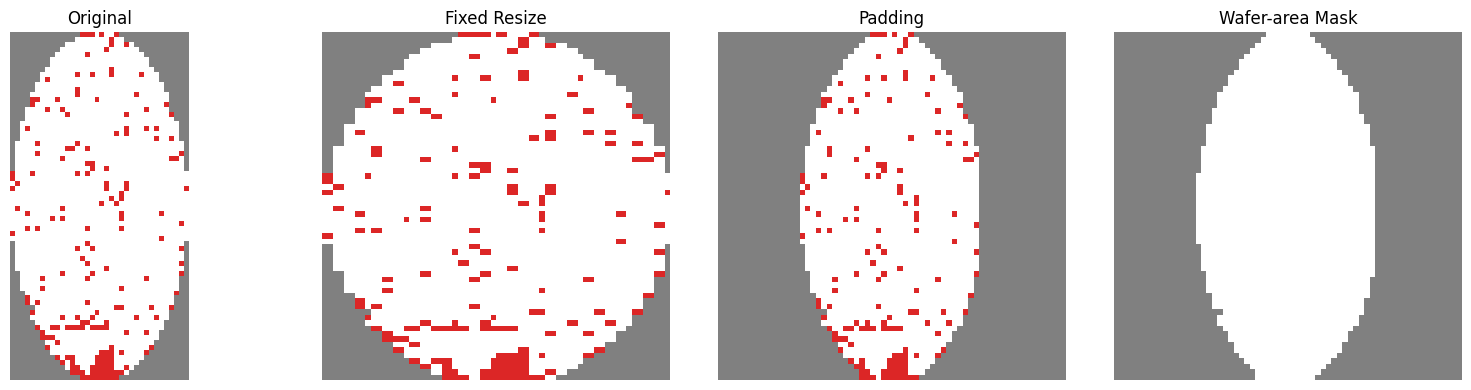

In [25]:
generated_paths = cover_paths + preprocess_paths
file_summary = pd.DataFrame(
    [
        {
            "group": "cover" if path.parent == COVER_DIR else "preprocessing",
            "filename": path.name,
            "absolute_path": str(path.resolve()),
            "size_bytes": path.stat().st_size,
            "pixel_size": Image.open(path).size,
            "mode": Image.open(path).mode,
        }
        for path in generated_paths
    ]
)
display(file_summary)

figure, axes = plt.subplots(1, 4, figsize=(16, 4))
preview_titles = [
    "Original",
    "Fixed Resize",
    "Padding",
    "Wafer-area Mask",
]
for axis, path, title in zip(axes, preprocess_paths, preview_titles):
    with Image.open(path) as image:
        axis.imshow(image, interpolation="nearest")
    axis.set_title(title)
    axis.axis("off")
# figure.suptitle("Preprocessing preview — 동일 raw sample")
figure.tight_layout()
plt.show()

C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:102: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(rgba, "RGBA")


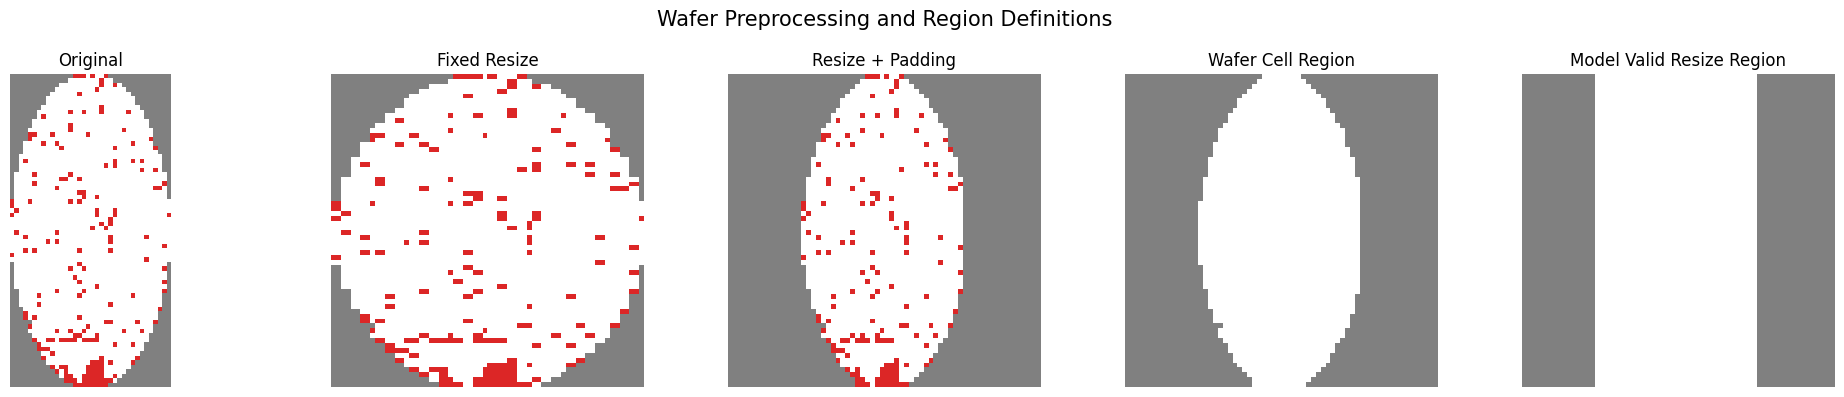

원래 모델 mask 저장 완료:
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\preprocessing\preprocess_05_model_valid_resize_region.png
5단계 비교 이미지 저장 완료:
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\preprocessing\preprocess_comparison_with_regions.png


In [26]:
# modeling.ipynb의 원래 valid-area mask 생성
padded_with_original_mask, model_valid_resize_region = (
    preprocess_resize_pad_with_mask(
        raw_sample,
        TARGET_SIZE,
    )
)

assert np.array_equal(
    padded_sample,
    padded_with_original_mask,
)

model_valid_region_path = (
    PREPROCESS_DIR / "preprocess_05_model_valid_resize_region.png"
)
comparison_preview_path = (
    PREPROCESS_DIR / "preprocess_comparison_with_regions.png"
)

save_mask_png(
    model_valid_resize_region,
    model_valid_region_path,
)

region_comparison_paths = preprocess_paths + [
    model_valid_region_path,
]
region_comparison_titles = [
    "Original",
    "Fixed Resize",
    "Resize + Padding",
    "Wafer Cell Region",
    "Model Valid Resize Region",
]

figure, axes = plt.subplots(1, 5, figsize=(20, 4))

for axis, path, title in zip(
    axes,
    region_comparison_paths,
    region_comparison_titles,
):
    with Image.open(path) as image:
        axis.imshow(image, interpolation="nearest")

    axis.set_title(title)
    axis.axis("off")

figure.suptitle(
    "Wafer Preprocessing and Region Definitions",
    fontsize=15,
)
figure.tight_layout()
figure.savefig(
    comparison_preview_path,
    dpi=240,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print("원래 모델 mask 저장 완료:")
print(model_valid_region_path)
print("5단계 비교 이미지 저장 완료:")
print(comparison_preview_path)

## 13. EDA

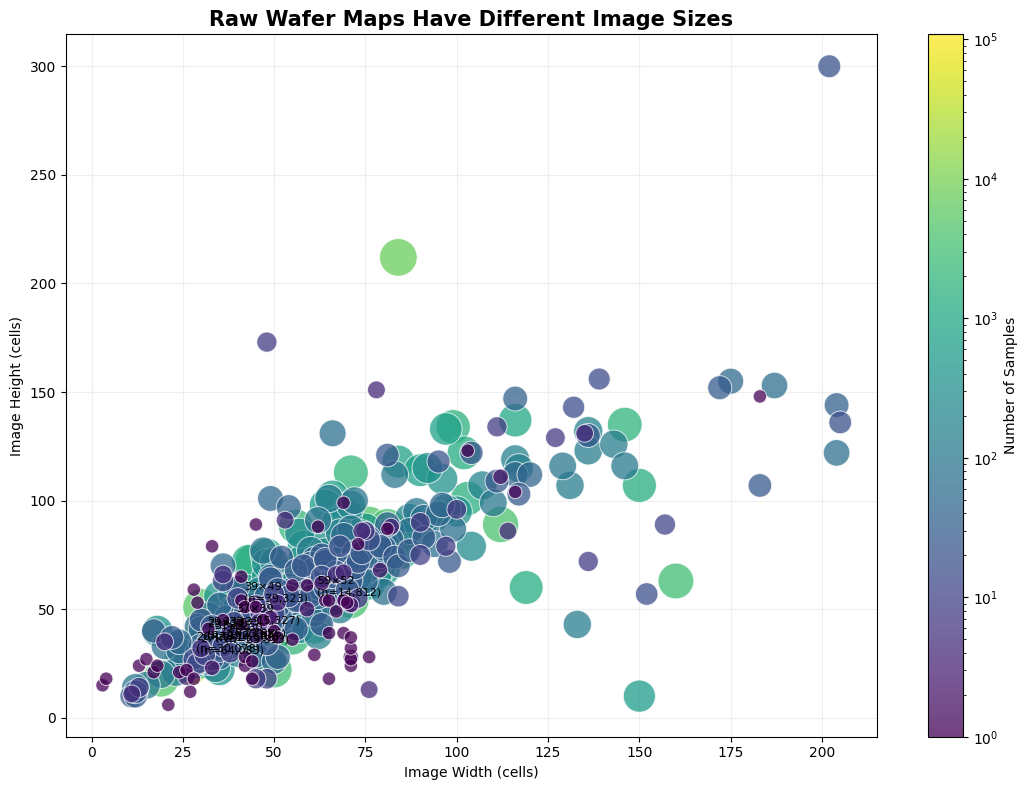

고유 이미지 크기 수: 632
원본 크기 범위: 3~205 width, 6~300 height
이미지 크기 분포 저장 완료:
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\dataset_image_size_variation.png


,width,height,sample_count
0,29,32,108687
1,27,25,64083
2,39,49,39323
3,26,26,30078
4,34,30,29513
5,33,33,23886
6,29,33,20276
7,37,39,15327
8,59,52,14812
9,31,31,14569


In [27]:
from matplotlib.colors import LogNorm


def summarize_image_sizes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """웨이퍼 맵의 원본 이미지 크기별 표본 수를 집계한다.

    Args:
        dataframe: waferMap 컬럼을 포함한 원본 데이터프레임.

    Returns:
        너비, 높이와 해당 크기의 표본 수를 담은 데이터프레임.
    """
    size_records = []

    for wafer_map in dataframe["waferMap"]:
        if not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
            continue

        height, width = wafer_map.shape
        size_records.append(
            {
                "width": int(width),
                "height": int(height),
            }
        )

    size_df = pd.DataFrame(size_records)

    return (
        size_df.groupby(["width", "height"])
        .size()
        .rename("sample_count")
        .reset_index()
        .sort_values(
            ["sample_count", "width", "height"],
            ascending=[False, True, True],
            kind="stable",
        )
        .reset_index(drop=True)
    )


image_size_summary = summarize_image_sizes(raw_df)

max_count = image_size_summary["sample_count"].max()
marker_sizes = (
    40
    + 900
    * np.log1p(image_size_summary["sample_count"])
    / np.log1p(max_count)
)

size_variation_path = (
    OUTPUT_DIR / "dataset_image_size_variation.png"
)

figure, axis = plt.subplots(figsize=(11, 8))

scatter = axis.scatter(
    image_size_summary["width"],
    image_size_summary["height"],
    s=marker_sizes,
    c=image_size_summary["sample_count"],
    cmap="viridis",
    norm=LogNorm(),
    alpha=0.75,
    edgecolors="white",
    linewidths=0.7,
)

# 표본 수가 많은 대표 크기 표시
for row in image_size_summary.head(10).itertuples():
    axis.annotate(
        f"{row.width}×{row.height}\n(n={row.sample_count:,})",
        xy=(row.width, row.height),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=8,
    )

colorbar = figure.colorbar(scatter, ax=axis)
colorbar.set_label("Number of Samples")

axis.set_title(
    "Raw Wafer Maps Have Different Image Sizes",
    fontsize=15,
    weight="bold",
)
axis.set_xlabel("Image Width (cells)")
axis.set_ylabel("Image Height (cells)")
axis.grid(alpha=0.2)
axis.set_axisbelow(True)

figure.tight_layout()
figure.savefig(
    size_variation_path,
    dpi=240,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print(f"고유 이미지 크기 수: {len(image_size_summary):,}")
print(
    "원본 크기 범위: "
    f"{image_size_summary['width'].min()}~"
    f"{image_size_summary['width'].max()} width, "
    f"{image_size_summary['height'].min()}~"
    f"{image_size_summary['height'].max()} height"
)
print("이미지 크기 분포 저장 완료:")
print(size_variation_path)

display(image_size_summary.head(15))

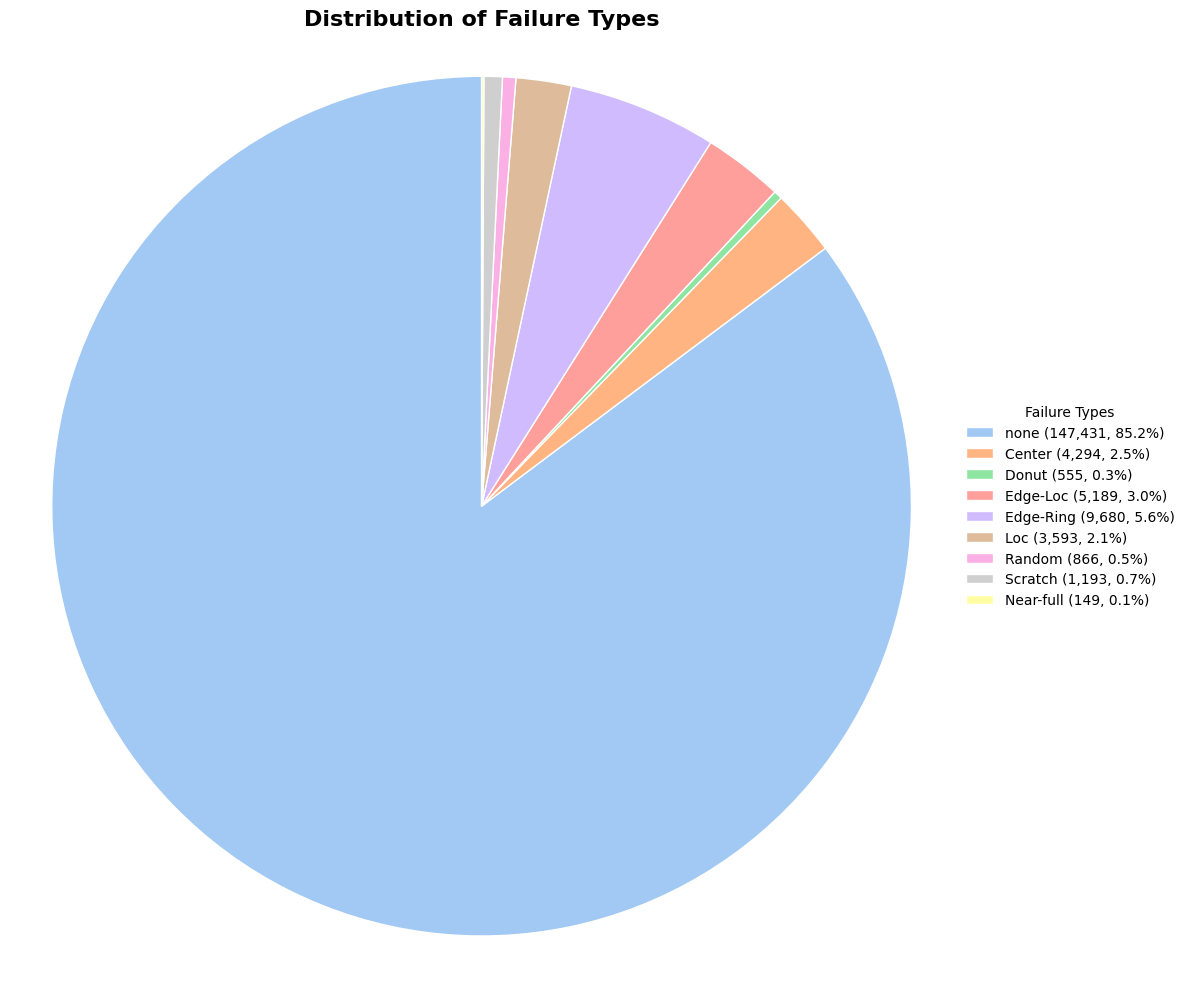

Failure type 분포 이미지 저장 완료:
C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\failure_type_distribution.png


In [33]:
import seaborn as sns


failure_type_order = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

valid_failure_types = failure_types[
    failure_types.isin(failure_type_order)
]
failure_type_counts = (
    valid_failure_types.value_counts()
    .reindex(failure_type_order, fill_value=0)
    .astype(int)
)

percentages = (
    failure_type_counts
    / failure_type_counts.sum()
    * 100
)
legend_labels = [
    f"{label} ({count:,}, {percentage:.1f}%)"
    for label, count, percentage in zip(
        failure_type_counts.index,
        failure_type_counts,
        percentages,
    )
]

failure_distribution_path = (
    OUTPUT_DIR / "failure_type_distribution.png"
)

colors = sns.color_palette(
    "pastel",
    n_colors=len(failure_type_counts),
)

figure, axis = plt.subplots(figsize=(12, 10))

axis.pie(
    failure_type_counts,
    startangle=90,
    colors=colors,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1,
    },
)

axis.set_title(
    "Distribution of Failure Types",
    fontsize=16,
    weight="bold",
)
axis.axis("equal")

axis.legend(
    legend_labels,
    title="Failure Types",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    # fontsize=14,
    # title_fontsize=16,
)

figure.tight_layout()
figure.savefig(
    failure_distribution_path,
    dpi=240,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print("Failure type 분포 이미지 저장 완료:")
print(failure_distribution_path)

## 14. Data Augmentation

In [38]:
def rotate_wafer_map(
    wafer_map: np.ndarray,
    angle: float,
) -> np.ndarray:
    """웨이퍼 맵을 지정한 각도로 회전한다.

    Args:
        wafer_map: 전처리가 완료된 웨이퍼 맵.
        angle: 반시계 방향 회전 각도.

    Returns:
        최근접 보간법으로 회전한 웨이퍼 맵.
    """
    height, width = wafer_map.shape
    center = (
        (width - 1) / 2.0,
        (height - 1) / 2.0,
    )
    rotation_matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0,
    )

    return cv2.warpAffine(
        wafer_map,
        rotation_matrix,
        (width, height),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )


AUGMENTATION_DIR = OUTPUT_DIR / "augmentation"
AUGMENTATION_DIR.mkdir(parents=True, exist_ok=True)

# 실제 모델 증강 직전 입력인 padding 결과 사용
preferred_augmentation_classes = [
    "Scratch",
    "Edge-Loc",
    "Loc",
    "Random",
    "Center",
    "Donut",
    "Edge-Ring",
    "Near-full",
]

augmentation_candidates = defect_metadata[
    (defect_metadata["height"] == defect_metadata["width"])
    & (defect_metadata.index != preprocess_index)
].copy()

augmentation_candidates["defect_cells"] = [
    int(np.count_nonzero(raw_df.at[index, "waferMap"] == 2))
    for index in augmentation_candidates.index
]
augmentation_candidates["wafer_cells"] = [
    int(np.count_nonzero(raw_df.at[index, "waferMap"] > 0))
    for index in augmentation_candidates.index
]

# 너무 희미한 불량 패턴 제외
augmentation_candidates = augmentation_candidates[
    augmentation_candidates["defect_cells"] >= 10
].copy()

class_priority = {
    class_name: rank
    for rank, class_name in enumerate(
        preferred_augmentation_classes
    )
}
augmentation_candidates["class_priority"] = (
    augmentation_candidates["failure_type"]
    .map(class_priority)
    .fillna(len(class_priority))
)

augmentation_candidates = augmentation_candidates.sort_values(
    [
        "class_priority",
        "defect_cells",
        "wafer_cells",
    ],
    ascending=[True, False, False],
    kind="stable",
)

if augmentation_candidates.empty:
    raise RuntimeError(
        "조건을 만족하는 1:1 augmentation 샘플이 없습니다."
    )

augmentation_index = int(augmentation_candidates.index[0])
augmentation_row = augmentation_candidates.loc[
    augmentation_index
]

augmentation_raw_sample = raw_df.at[
    augmentation_index,
    "waferMap",
].astype(
    np.uint8,
    copy=False,
)

# 모델 증강 직전과 동일하게 64×64로 전처리
augmentation_source = preprocess_resize_pad(
    augmentation_raw_sample,
    TARGET_SIZE,
)

print(f"선택 index: {augmentation_index}")
print(f"class: {augmentation_row['failure_type']}")
print(
    "original shape: "
    f"{augmentation_raw_sample.shape}"
)
print(
    "defect cells: "
    f"{augmentation_row['defect_cells']}"
)

horizontal_flip = np.ascontiguousarray(
    np.fliplr(augmentation_source)
)
vertical_flip = np.ascontiguousarray(
    np.flipud(augmentation_source)
)
rotation_15 = rotate_wafer_map(
    augmentation_source,
    angle=15,
)

augmentation_paths = {
    "original": AUGMENTATION_DIR / "augmentation_01_original.png",
    "horizontal_flip": (
        AUGMENTATION_DIR / "augmentation_02_horizontal_flip.png"
    ),
    "vertical_flip": (
        AUGMENTATION_DIR / "augmentation_03_vertical_flip.png"
    ),
    "rotation_15": (
        AUGMENTATION_DIR / "augmentation_04_rotation_15.png"
    ),
}

save_square_map_png(
    augmentation_source,
    augmentation_paths["original"],
)
save_square_map_png(
    horizontal_flip,
    augmentation_paths["horizontal_flip"],
)
save_square_map_png(
    vertical_flip,
    augmentation_paths["vertical_flip"],
)
save_square_map_png(
    rotation_15,
    augmentation_paths["rotation_15"],
)

print("Augmentation 이미지 저장 완료")
for name, path in augmentation_paths.items():
    print(f"{name}: {path}")

선택 index: 300793
class: Scratch
original shape: (81, 81)
defect cells: 405
Augmentation 이미지 저장 완료
original: C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\augmentation\augmentation_01_original.png
horizontal_flip: C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\augmentation\augmentation_02_horizontal_flip.png
vertical_flip: C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\augmentation\augmentation_03_vertical_flip.png
rotation_15: C:\Users\ilove\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\data\wafer_images\augmentation\augmentation_04_rotation_15.png


C:\Users\ilove\AppData\Local\Temp\ipykernel_29284\3958559805.py:81: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(map_to_rgba(wafer_map, BACKGROUND_GRAY), "RGBA")
